# Wyżarzacze kwantowe

Wyżarzaczem kwantowym nazywamy maszynę która fizycznie implementuje algorytm wyżarzania kwantowego. Obecnie najpopularniejsze są urządzenia produkowane przez firmę DWave. W sercu każdej maszyny leży procesor kwantowy, *Quantum Proccesing Unit* (QPU), składający się z kubitów połączonych couplerami (czasami słowo *coupler* tłumaczy się jako "sprzęgacz"). W tym szkoleniu nie będziemy wdawać się w szczegóły jak te kubity i couplery fizycznie wyglądają. Strukturę połączeń między kubitami w QPU nazywamy **topologią**.  

## Topologie procesorów DWave

### Chimera

Jest to pierwsza i najstarsza z istniejących topologii. Składa się z komórek jednostkowych (ang. *Unit Cell*) połączonych ze sobą w kształt kraty. Każda z komórek składa się z ośmiu kubitów połączonych ze sobą jak pełny graf dwudzielny $K_{4, 4}$. Poniżej jest przedstawiony przykład Chimery **C2**

<img src="pictures/chimera.png" width="700" height="700" />

### Pegasus

WIP, jak zawsze problem ze śmiecami na brzegach

### Zephyr

Najnowocześniejsza topologia. Urządzenia które ją implementują są obecnie w fazie prototypów. **Z2** czyli zephyr złorzony z 2x2 komórek jednostkowych. Na pierwszy rzut oka widać zarówno więcej kubitów jak i znacznie gęściejszą siatkę połączeń.


![image](pictures/zephyr.png)

## Embedding

Z powodu tego jak jest skonstuowana sieć połączeń w QPU, wiele problemów trzeba embeddować (albo zanurzać) w grafie topologii QPU.

Znaleziono embedding:
  K3 wierzchołek 0 -> wierzchołek 1
  K3 wierzchołek 1 -> łańcuch [0, 5]
  K3 wierzchołek 2 -> wierzchołek 7


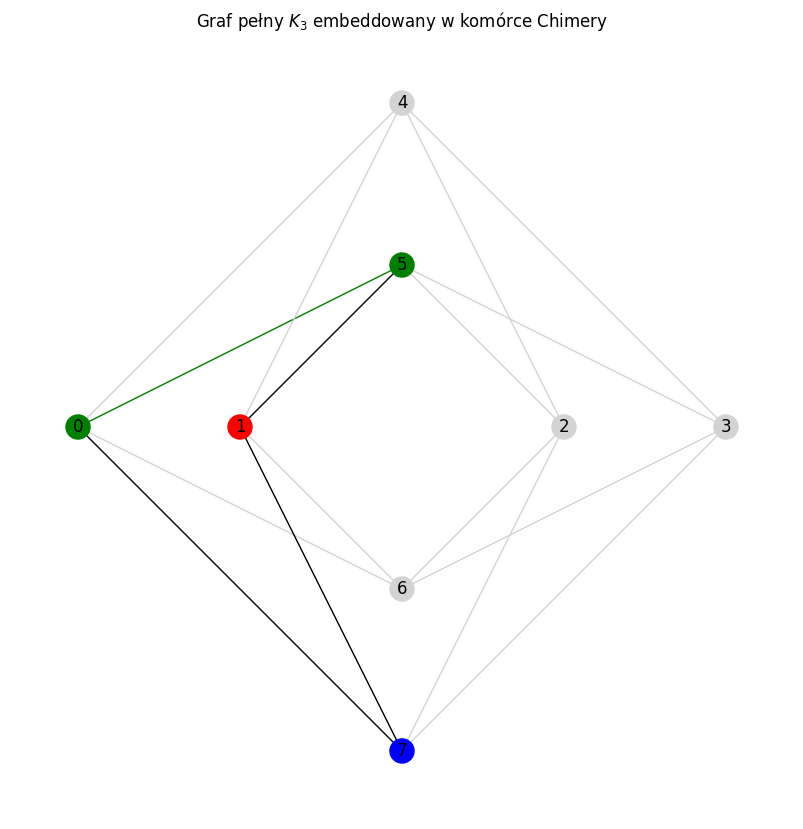

In [ ]:
import networkx as nx
import dwave_networkx as dnx
import minorminer
import matplotlib.pyplot as plt


chimera = dnx.chimera_graph(1, 1, 4)
K3 = nx.complete_graph(3)

embedding = minorminer.find_embedding(K3, chimera)
print("Znaleziono embedding:")
for k3_node, chain in embedding.items():
    if len(chain) > 1:
        print(f"  K3 wierzchołek {k3_node} -> łańcuch {chain}")
    else:
        print(f"  K3 wierzchołek {k3_node} -> wierzchołek {chain[0]}")



chain_colors = {k: color for k, color in zip(embedding.keys(), ["red", "green", "blue", "purple"])}

# Budujemy mapę kolorów dla komórki chimery
node_color = {}
edge_color = {}

for k3_node, chain in embedding.items():
    for q in chain:
        node_color[q] = chain_colors[k3_node]
    if len(chain) > 1:
        v, w = chain
        edge_color[(v, w)] = chain_colors[k3_node]
        edge_color[(w, v)] = chain_colors[k3_node]

for (v, w) in K3.edges():
    x = embedding[v]
    y = embedding[w]
    if len(x) == len(y) == 1:
        edge_color[(x[0], y[0])] = "black"
        edge_color[(y[0], x[0])] = "black"
    elif len(x) > 1:
        edge_color[(x[0], y[0])] = "black"
        edge_color[(y[0], x[0])] = "black"
        edge_color[(x[1], y[0])] = "black"
        edge_color[(y[0], x[1])] = "black"
    else:
        edge_color[(x[0], y[0])] = "black"
        edge_color[(y[0], x[0])] = "black"
        edge_color[(x[0], y[1])] = "black"
        edge_color[(y[1], x[0])] = "black"
    
# TODO: napisz lepiej
    
    


# Kolor dla kubitów i krawędzi nie używanych w embeddingu
default_color = "lightgray"

node_colors = [node_color.get(node, default_color) for node in chimera.nodes()]
edge_colors = [edge_color.get(edge, default_color) for edge in chimera.edges()]


plt.figure(figsize=(8, 8))
dnx.draw_chimera(chimera, node_color=node_colors, edge_color=edge_colors, with_labels=True, node_size=300)
plt.title(rf"Graf pełny $K_3$ embeddowany w komórce Chimery")
plt.show()

# Ocean Software

Ocean Software to zestaw narzędzi programistycznych, umożliwiający modelowanie i rozwiązywanie problemów optymalizacyjnych przy użyciu kwantowych procesorów wyżarzania. Składa się z wielu powiązanych ze sobą paczek w pythonie które pozwalają modelować problemy optymalizacyjne, mapować je na odpowiednie formaty i przesyłać do rozwiązywania na komputerach kwantowych D-Wave.

In [ ]:
# niezbędy token by móc się połączyć
with open("token.txt", "r") as f:
    token = f.read()

#Zdefiniowanie maszyny której będziemy używać
from dwave.system import DWaveSampler

sampler = DWaveSampler(token=token)

# Parametry maszyny do której mamy dostęp
print("Parametry: ")
print("QPU: ", sampler.properties["chip_id"] )
print("Architektura: ", sampler.properties["topology"])
print("Ilość kubitów: ", sampler.properties["num_qubits"])
print("Ilość połączen: ", len(sampler.properties["couplers"]))

In [ ]:
# Ważne: Trzeba pamiętać o zrobieniu dwave setup
from dwave.system import  AutoEmbeddingComposite
import dwave.inspector

import networkx as nx

# tworzymy problem za pomocą słowników
graph = nx.complete_graph(6)
h = {node: 0.5 for node in graph.nodes}
J = {edge: 1 for edge in graph.edges}

# automatycznie mapujemy nasz problem na QPU
solver = AutoEmbeddingComposite(sampler)

# Rozwiązujemy problem
solution = solver.sample_ising(h, J)
dwave.inspector.show(solution)